# Pentax K1000 Light Meter Calibration

This notebook analyzes the variable resistors in the Pentax K1000 light meter system and helps calibrate the light meter circuit for accurate exposure measurement.

## Calibration Process Overview

1. **Variable Resistor Linearity Analysis**: Check aperture, shutter speed, and light meter circuit resistors
2. **Circuit Modeling**: Model the complete circuit and calculate EV (Exposure Value) errors
3. **Resistor Recommendation**: Suggest optimal adjustment resistor values

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import calibration utilities
from k1000_calibration import (
    analyze_aperture_resistor,
    analyze_shutter_resistor,
    analyze_light_meter_circuit,
    calculate_ev_errors,
    recommend_adjustment_resistor,
    generate_calibration_report
)

# Import ipydatagrid for interactive data entry
from ipydatagrid import DataGrid

## 1. Aperture Variable Resistor Linearity Check

Enter the resistance measurements for different f-stop values. The aperture wheel variable resistor should show linear resistance change across the f-stop range.

In [2]:
# Aperture Resistor Data Entry
# Typical K1000 f-stops: 1.4, 2, 2.8, 4, 5.6, 8, 11, 16, 22

aperture_data = {
    'F-Stop': [1.4, 2.0, 2.8, 4.0, 5.6, 8.0, 11.0, 16.0, 22.0],
    'Resistance (Ω)': [np.nan]*9
}

aperture_df = pd.DataFrame(aperture_data)
print("Enter aperture resistor measurements in the table below:")
aperture_grid = DataGrid(aperture_df, editable=True)
display(aperture_grid)

Enter aperture resistor measurements in the table below:


DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

=== APERTURE RESISTOR LINEARITY ANALYSIS ===
Transformation tested: f-stop, f², log(f-stop), 1/f²
Best fit: log(f-stop)

R² Value: 0.9997 (1.0 = perfect linearity)
RMS Error: 42.24 Ω
Maximum Deviation: 73.33 Ω
Linearity: 99.16%
Slope: 2906.3866 Ω/log(f-stop)

Comparison of all transformations:
  log(f-stop)    : R² = 0.9997
  f-stop         : R² = 0.8810
  f²             : R² = 0.6913
  1/f²           : R² = 0.6742


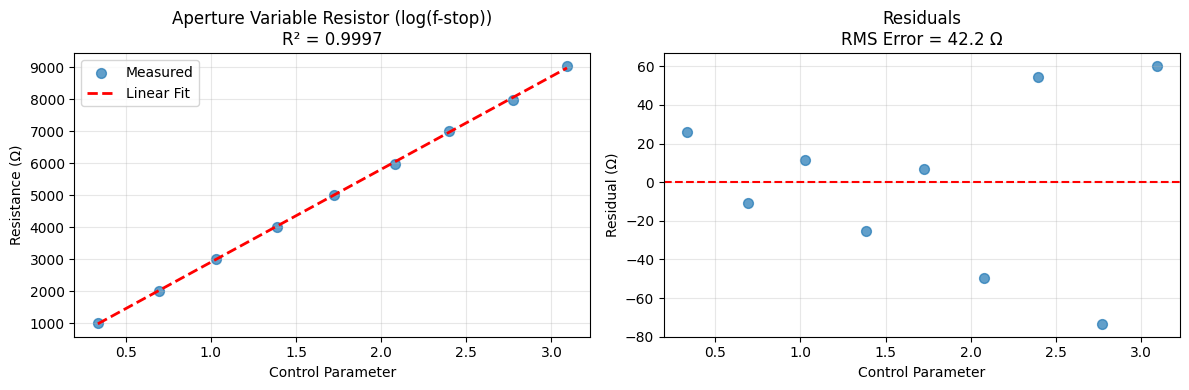

In [3]:
# Analyze Aperture Resistor Linearity
aperture_analysis = analyze_aperture_resistor(aperture_grid)

## 2. Shutter Speed Resistor Linearity Check

Enter resistance measurements for different shutter speeds at 100 ASA. The shutter speed cam should produce linear resistance change across the speed range.

In [4]:
# Shutter Speed Resistor Data Entry at 100 ASA
# Typical K1000 speeds: 1, 2, 4, 8, 15, 30, 60, 125, 250, 500, 1000

shutter_data = {
    'Shutter Speed (1/s)': [1, 2, 4, 8, 15, 30, 60, 125, 250, 500, 1000],
    'Resistance (Ω)': [np.nan]*11
}

shutter_df = pd.DataFrame(shutter_data)
print("Enter shutter speed resistor measurements (at 100 ASA) in the table below:")
shutter_grid = DataGrid(shutter_df, editable=True)
display(shutter_grid)

Enter shutter speed resistor measurements (at 100 ASA) in the table below:


DataGrid(auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_renderer=None, default_render…

=== SHUTTER SPEED RESISTOR LINEARITY ANALYSIS ===
R² Value: 0.9999 (1.0 = perfect linearity)
RMS Error: 34.34 Ω
Maximum Deviation: 59.76 Ω
Linearity: 99.43%
Slope: 1004.2554 Ω/LOG₂(speed)


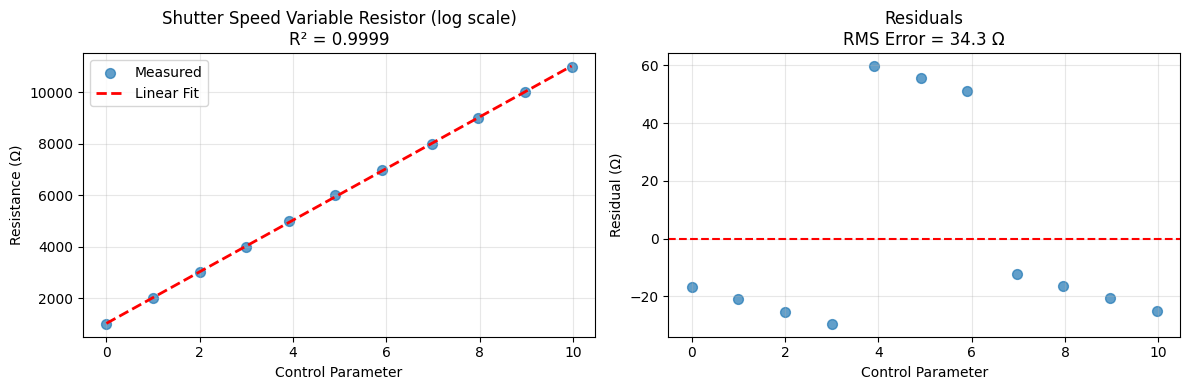

In [5]:
# Analyze Shutter Speed Resistor Linearity
shutter_analysis = analyze_shutter_resistor(shutter_grid)

## 3. Light Meter Circuit Resistance Analysis

Enter the measured resistance of the light meter circuit at different EV (Exposure Value) levels. Each EV step represents a one-stop change in exposure.

In [ ]:
# Light Meter Circuit Resistance Data Entry
# EV values represent different lighting conditions
# Typical range: EV 2-16 for normal photography

light_meter_data = {
    'EV Level': [2, 4, 6, 8, 10, 12, 14, 16],
    'Circuit Resistance (Ω)': [np.nan]*8
}

lightem_df = pd.DataFrame(light_meter_data)
print("Enter light meter circuit resistance measurements in the table below:")
lightem_grid = DataGrid(lightem_df, editable=True)
display(lightem_grid)

Enter light meter circuit resistance measurements:
 EV Level  Circuit Resistance (Ω)
        2                     NaN
        4                     NaN
        6                     NaN
        8                     NaN
       10                     NaN
       12                     NaN
       14                     NaN
       16                     NaN

Update the DataFrame above with your measurements and run the next cell


In [ ]:
# Analyze Light Meter Circuit Linearity
lm_analysis = analyze_light_meter_circuit(lightem_grid)
lightem_df = lightem_grid.data

## 4. Circuit Modeling and EV Error Analysis

This section models the complete light meter circuit and calculates the exposure error (in stops/EV) that results from resistance variations.

In [ ]:
# Calculate and Visualize EV Error
if not any(np.isnan(np.array(lightem_df['Circuit Resistance (Ω)']))):
    # Calculate EV errors from measured vs ideal linear relationship
    measured_r = np.array(lightem_df['Circuit Resistance (Ω)'])
    ev_levels = np.array(lightem_df['EV Level'])
    
    # Expected resistance following perfect linear relationship
    expected_r = lm_analysis['slope'] * ev_levels + lm_analysis['intercept']
    
    # Calculate EV error for each measurement
    ev_errors = []
    for i, (meas, exp) in enumerate(zip(measured_r, expected_r)):
        if exp > 0 and meas > 0:
            ev_error = np.log2(meas / exp)
        else:
            ev_error = 0
        ev_errors.append(ev_error)
    
    ev_errors = np.array(ev_errors)
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    
    # Plot 1: Measured vs Expected Resistance
    ax1.scatter(ev_levels, measured_r, label='Measured', s=80, alpha=0.7, color='blue')
    ax1.plot(ev_levels, expected_r, 'r--', label='Linear Fit', linewidth=2)
    ax1.set_xlabel('EV Level')
    ax1.set_ylabel('Resistance (Ω)')
    ax1.set_title('Light Meter Circuit: Measured vs Expected Resistance')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: EV Error
    colors = ['red' if e > 0.1 else 'orange' if e > 0.05 else 'green' for e in np.abs(ev_errors)]
    ax2.bar(ev_levels, ev_errors, color=colors, alpha=0.7, edgecolor='black')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax2.axhline(y=0.1, color='red', linestyle='--', linewidth=1, alpha=0.5, label='±0.1 EV threshold')
    ax2.set_xlabel('EV Level')
    ax2.set_ylabel('EV Error (stops)')
    ax2.set_title('Exposure Error Across EV Range')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print error statistics
    print("\n=== EV ERROR ANALYSIS ===")
    print(f"Maximum EV Error: {np.max(np.abs(ev_errors)):.3f} stops")
    print(f"RMS EV Error: {np.sqrt(np.mean(ev_errors**2)):.3f} stops")
    print(f"Mean Signed Error: {np.mean(ev_errors):.3f} stops")
    print(f"\nError Distribution:")
    print(f"  Within ±0.05 EV: {np.sum(np.abs(ev_errors) <= 0.05)} points")
    print(f"  Within ±0.1 EV:  {np.sum(np.abs(ev_errors) <= 0.1)} points")
    print(f"  > ±0.1 EV:       {np.sum(np.abs(ev_errors) > 0.1)} points")
else:
    print("No light meter data entered yet. Please fill in measurements to see EV error analysis.")

## 5. Adjustment Resistor Recommendation

This section suggests optimal adjustment resistor values to minimize exposure error across the operating range.

In [ ]:
# Calculate Optimal Adjustment Resistor
if not any(np.isnan(np.array(lightem_df['Circuit Resistance (Ω)']))):
    measured_r = np.array(lightem_df['Circuit Resistance (Ω)'], dtype=float)
    ev_vals = np.array(lightem_df['EV Level'], dtype=float)
    
    optimal_r, max_error, status = find_optimal_adjustment_resistor(measured_r, ev_vals)
    
    print("=== ADJUSTMENT RESISTOR RECOMMENDATION ===")
    if status == "success":
        print(f"Optimal adjustment resistor: {optimal_r:.1f} Ω")
        print(f"Maximum EV error with adjustment: {max_error:.3f} stops")
        print(f"\nConfiguration suggestions:")
        print(f"  - Use {optimal_r:.0f} Ω trimmer potentiometer (closest standard value)")
        print(f"  - Connect in parallel with main circuit for fine adjustment")
        print(f"  - Expected accuracy: ±{max_error*2:.2f} EV (±{max_error*2*100:.1f}% exposure error)")
    else:
        print("Cannot calculate recommendation - insufficient data")
        optimal_r = None
else:
    print("Please enter light meter circuit resistance measurements first.")
    optimal_r = None

## 6. Calibration Summary

Below is a summary of the complete calibration analysis.

In [ ]:
# Generate Calibration Summary Report
print(generate_calibration_report(
    aperture_analysis=aperture_analysis,
    shutter_analysis=shutter_analysis,
    lm_analysis=lm_analysis,
    lightem_df=lightem_df,
    ev_errors=ev_errors,
    optimal_r=optimal_r
))